# Erdos Project: Golden Handcuff

## Initial EDA: Orlando (tourism)

### Data Collection: (source, description, link, period, frequency)
1. FRED, 30-Year Fixed Rate Mortgage Average in the United States (MORTGAGE30US), https://fred.stlouisfed.org/series/MORTGAGE30US, from 2016-04-01 to 2026-02-19, weekly
2. FRED, Market Yield on U.S. Treasury Securities at 10-Year Constant Maturity, Quoted on an Investment Basis (GS10), https://fred.stlouisfed.org/series/GS10, from 2016-04-01 to 2026-01-01, monthly
3. FRED, Housing Inventory: New Listing Count in Orlando-Kissimmee-Sanford, FL (CBSA) (NEWLISCOU36740), https://fred.stlouisfed.org/series/NEWLISCOU36740, from 2016-07-01 to 2026-01-01, monthly
4. FRED, Housing Inventory: Active Listing Count in Orlando-Kissimmee-Sanford, FL (CBSA) (ACTLISCOU36740), https://fred.stlouisfed.org/series/ACTLISCOU36740, from 2016-06-01 to 2026-01-01, monthly
5. FRED, All-Transactions House Price Index for Orlando-Kissimmee-Sanford, FL (MSA) (ATNHPIUS36740Q), https://fred.stlouisfed.org/series/ATNHPIUS36740Q, from 2015-04-01 to 2025-10-01, quarterly
6. FRED, Unemployment Rate in Orlando-Kissimmee-Sanford, FL (MSA) (ORLA712URN), https://fred.stlouisfed.org/series/ORLA712URN, from 2015-04-01 to 2025-12-01, monthly
7. FRED, Resident Population in Orlando-Kissimmee-Sanford, FL (MSA) (ORLPOP), https://fred.stlouisfed.org/series/ORLPOP, from 2000-01-01 to 2024-01-01, annual


### Data preprocessing: make everything weekly and merge to one data frame

In [23]:
import pandas as pd
import numpy as np

DATA_DIR = r"E:\Erdos_DS_BootCamp\Project_my_work\Orlando_data"
# convert 30 year fixed rate mortage average from weekly to monthly
mortgage_weekly = pd.read_csv(
    fr'{DATA_DIR}\MORTGAGE30US.csv',
    parse_dates=['observation_date']
)
mortgage_weekly = mortgage_weekly.set_index('observation_date').sort_index()
mortgage = mortgage_weekly.resample('MS').mean()

# convert all transactions house price index from quarterly to monthly (forward fill)
hpi_quarterly = pd.read_csv(
    fr'{DATA_DIR}\ATNHPIUS36740Q.csv',
    parse_dates=['observation_date']
)
hpi_quarterly = hpi_quarterly.set_index('observation_date')
hpi = hpi_quarterly.resample('MS').ffill()

# convert resident population in Orlando-Kissimmee-Sanford from annual to monthly (forward fill)
pop_annual = pd.read_csv(
    fr'{DATA_DIR}\ORLPOP.csv',
    parse_dates=['observation_date']
)
pop_annual= pop_annual.set_index('observation_date')
pop = pop_annual.resample('MS').ffill()

In [ ]:
# read all the monthly data
gs10 = pd.read_csv(
    fr"{DATA_DIR}\GS10.csv",
    parse_dates=["observation_date"]
)
gs10 = gs10.set_index("observation_date").sort_index()

newl = pd.read_csv(
    fr"{DATA_DIR}\NEWLISCOU36740.csv",
    parse_dates=["observation_date"]
)
newl = newl.set_index("observation_date").sort_index()

actl = pd.read_csv(
    fr"{DATA_DIR}\ACTLISCOU36740.csv",
    parse_dates=["observation_date"]
)
actl = actl.set_index("observation_date").sort_index()

unemp = pd.read_csv(
    fr"{DATA_DIR}\ORLA712URN.csv",
    parse_dates=["observation_date"]
)
unemp = unemp.set_index("observation_date").sort_index()

In [4]:
# merge into one dataframe
df = pd.concat(
    [mortgage, gs10, newl, actl, hpi, unemp, pop],
    axis=1,
    sort=False
).sort_index()

df = df.dropna().copy()

print("Common range:", df.index.min().date(), "to", df.index.max().date())

Common range: 2016-07-01 to 2024-01-01


In [5]:
new_column_names = ['mortgage', 'gs10', 'newl', 'actl', 'hpi', 'unemp', 'pop']
df.columns = new_column_names
df.sample(5)

,mortgage,gs10,newl,actl,hpi,unemp,pop
observation_date,,,,,,,
2021-07-01,2.8680,1.32,4856.0,4023.0,334.85,5.3,2699.313
2019-02-01,4.3700,2.68,4636.0,10326.0,261.16,3.1,2608.273
2018-06-01,4.5700,2.91,4640.0,9346.0,250.30,3.7,2576.297
2018-04-01,4.4675,2.87,4638.0,8940.0,250.30,3.2,2576.297
2021-09-01,2.9000,1.37,4376.0,4214.0,334.85,4.5,2699.313


### EDA:
1. Level plots of Mortgage rate, New listings, Active listings, HPI and Unemployment
2. Year-over-year change in new listings (remove seasonality)
3. Growth vs mortgage rate level

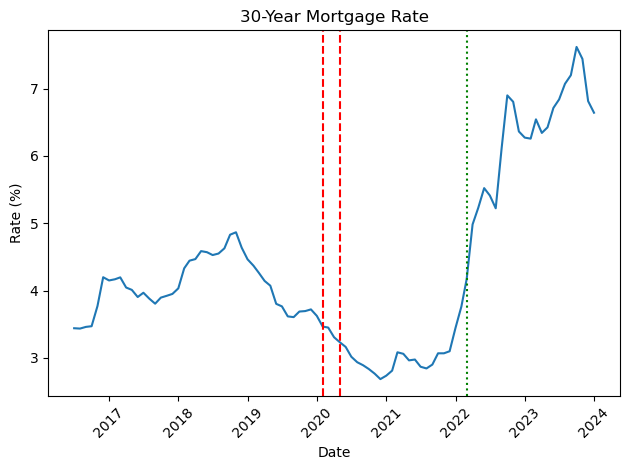

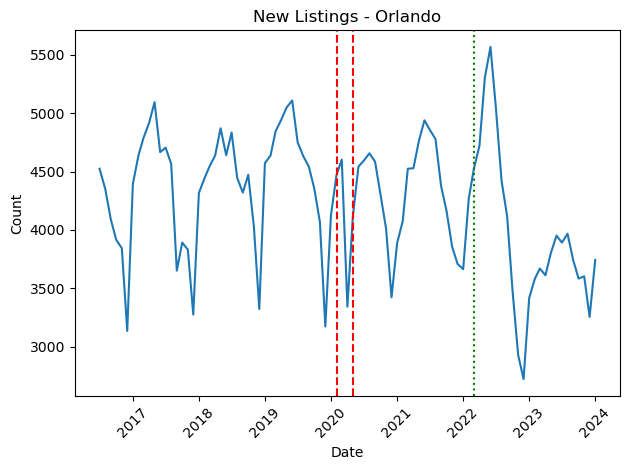

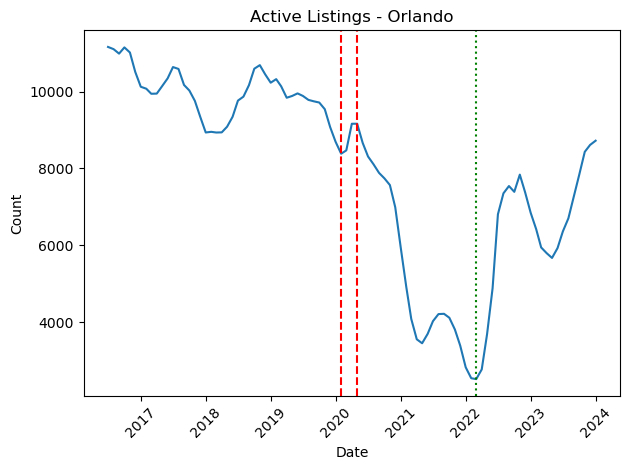

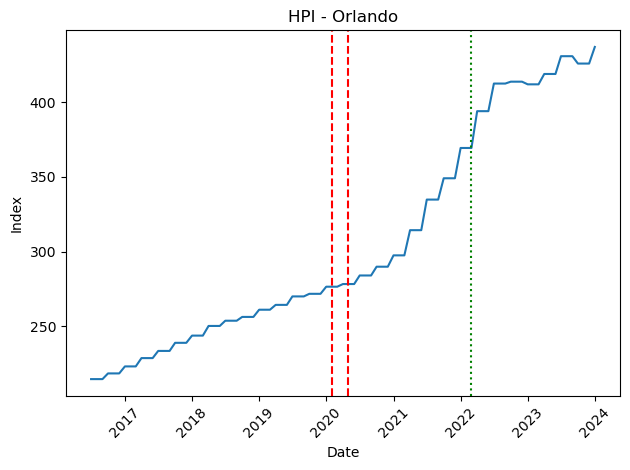

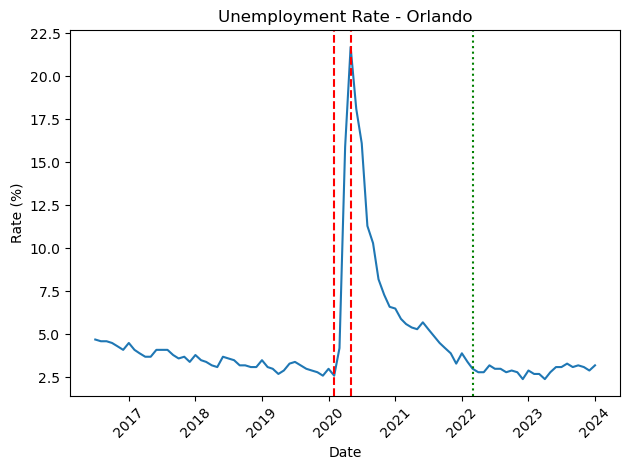

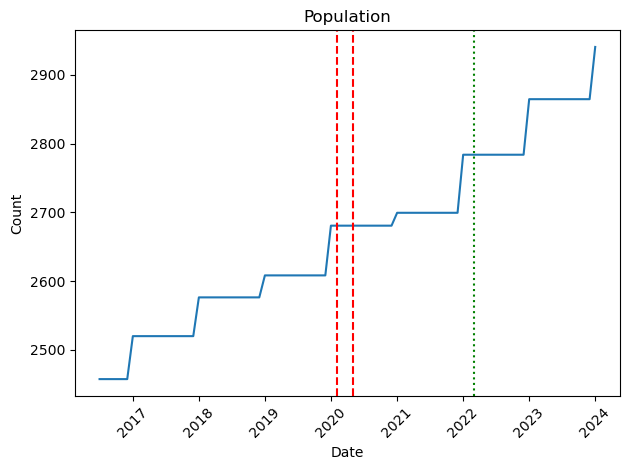

In [6]:
# 1. level plots with vertical lines for pandemic

import matplotlib.pyplot as plt

# Pandemic markers
pandemic_start = pd.Timestamp("2020-02-01")
pandemic_peak = pd.Timestamp("2020-05-01")
rate_hike_start  = pd.Timestamp("2022-03-01")

def plot_with_pandemic(df, column, title, ylabel):
    plt.figure()
    plt.plot(df.index, df[column])
    
    # Vertical lines
    plt.axvline(pandemic_start, linestyle='--', color='r')
    plt.axvline(pandemic_peak, linestyle='--', color='r')
    plt.axvline(rate_hike_start, linestyle=':', color='g')
    
    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel(ylabel)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# 1️ Mortgage
plot_with_pandemic(df, "mortgage", "30-Year Mortgage Rate", "Rate (%)")

# 2️ New Listings
plot_with_pandemic(df, "newl", "New Listings - Orlando", "Count")

# 3️ Active Listings
plot_with_pandemic(df, "actl", "Active Listings - Orlando", "Count")

# 4️ HPI
plot_with_pandemic(df, "hpi", "HPI - Orlando", "Index")

# 5️ Unemployment
plot_with_pandemic(df, "unemp", "Unemployment Rate - Orlando", "Rate (%)")

plot_with_pandemic(df, "pop", "Population", "Count")

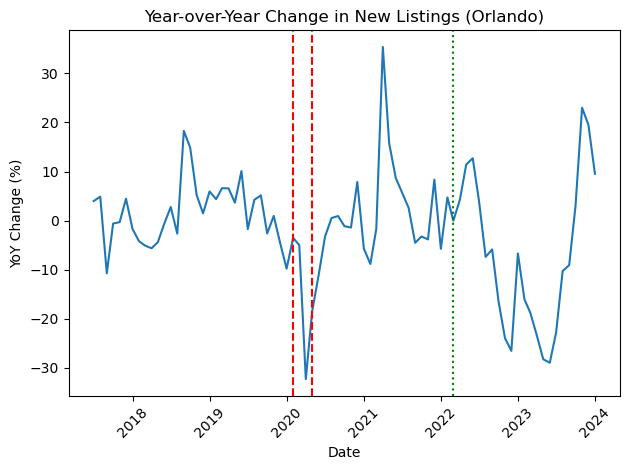

In [7]:
# 2. Year-over-year change in new listings (remove seasonality)

# Compute YoY percentage change
df["newl_yoy"] = df["newl"].pct_change(12) * 100

# Plot YoY change
plt.figure()
plt.plot(df.index, df["newl_yoy"])

plt.axvline(pandemic_start, linestyle='--', color='r')
plt.axvline(pandemic_peak, linestyle='--', color='r')
plt.axvline(rate_hike_start, linestyle=':', color='g')

plt.title("Year-over-Year Change in New Listings (Orlando)")
plt.xlabel("Date")
plt.ylabel("YoY Change (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

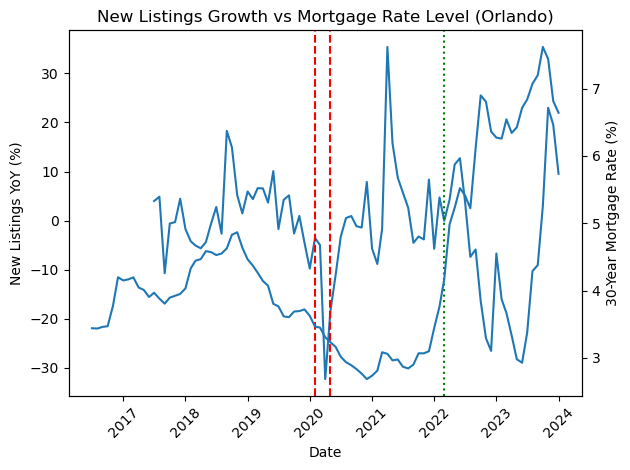

In [17]:
# 3. Growth v.s. mortgage rate level

fig, ax1 = plt.subplots()

# Left axis: YoY growth
ax1.plot(df.index, df["newl_yoy"])
ax1.set_xlabel("Date")
ax1.set_ylabel("New Listings YoY (%)")
ax1.tick_params(axis="x", rotation=45)

# Right axis: mortgage rate level
ax2 = ax1.twinx()
ax2.plot(df.index, df["mortgage"])
ax2.set_ylabel("30-Year Mortgage Rate (%)")

# Vertical lines
for d in [pandemic_start, pandemic_peak]:
    ax1.axvline(d, linestyle="--", color = 'r')
ax1.axvline(rate_hike_start, linestyle=":", color = 'g')

plt.title("New Listings Growth vs Mortgage Rate Level (Orlando)")
fig.tight_layout()
plt.show()

### Variables:
#### Dependent:
#### Independent:
#### Target:
#### Features:
#### Could be used in the future: 
active lisitngs

### PCA analysis
#### Macroeconomic indices: 
mortgage rate, 10-year treasury rate, HPI, unemployment rate, population


In [ ]:
# PCA for Orlando
# add new listings
# check sigular value distribution of PCA
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# PCA feature space (macro indices only)
pca_cols = ["mortgage", "gs10", "hpi", "unemp", "pop"] 

# 
X = df[pca_cols].copy()
X = X.sort_index()
X = X.dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# fit PCA
pca_full = PCA()
Z_full = pca_full.fit_transform(X_scaled)

# Explained variance ratio for each component
explained_var = pd.Series(
    pca_full.explained_variance_ratio_,
    index=[f"PC{i+1}" for i in range(Z_full.shape[1])]
)

# Loadings: how each original variable contributes to each PC
loadings = pd.DataFrame(
    pca_full.components_.T,
    index=X.columns,
    columns=[f"PC{i+1}" for i in range(Z_full.shape[1])]
)

print("Explained variance ratio:")
print(explained_var)

print("\nTop loadings (first 3 PCs):")
print(loadings.iloc[:, :3])

# Choose components
cumvar = explained_var.cumsum()
k = int(np.argmax(cumvar.values >= 0.80) + 1)

pca = PCA(n_components=k)
Z = pca.fit_transform(X_scaled)

pc_cols = [f"PC{i+1}" for i in range(k)]
df_pca = pd.DataFrame(Z, index=X.index, columns=pc_cols)

# Merge PCA to main data frame
df_with_pca = df.join(df_pca, how="left")

Explained variance ratio:
PC1    0.648237
PC2    0.250170
PC3    0.091735
PC4    0.005872
PC5    0.003986
dtype: float64

Top loadings (first 3 PCs):
               PC1       PC2       PC3
mortgage  0.516662 -0.131466  0.474398
gs10      0.486048 -0.348329  0.397604
hpi       0.481366  0.397190 -0.282256
unemp    -0.270433  0.662779  0.681482
pop       0.438144  0.514148 -0.269762


In [19]:
df_with_pca.sample(5)

,mortgage,gs10,newl,actl,hpi,unemp,pop,newl_yoy,PC1,PC2
observation_date,,,,,,,,,,
2022-09-01,6.1120,3.52,4118.0,7542.0,412.48,2.8,2783.767,-5.895795,2.531708,0.162704
2019-03-01,4.2650,2.57,4844.0,10139.0,261.16,3.0,2608.273,6.602113,-0.308393,-0.851516
2018-08-01,4.5500,2.89,4444.0,9871.0,253.80,3.5,2576.297,-2.671923,-0.245787,-1.063824
2021-03-01,3.0825,1.61,4524.0,4080.0,297.53,5.6,2699.313,-1.694915,-0.884791,0.705601
2019-07-01,3.7650,2.06,4750.0,9889.0,270.06,3.4,2608.273,-1.737691,-0.724916,-0.494747


## Expanding from Orlando to Florida

### Data Collection: (source, description, link, period, frequency)
3 ~ 7 for Florida

3. FRED, Housing Inventory: New Listing Count in Florida (NEWLISCOUFL), https://fred.stlouisfed.org/series/NEWLISCOUFL, from 2016-07-01 to 2026-01-01, monthly

4. FRED, Housing Inventory: Active Listing Count in Florida (ACTLISCOUFL), https://fred.stlouisfed.org/series/ACTLISCOUFL, from 2016-07-01 to 2026-01-01, monthly

5. FRED, All-Transactions House Price Index for Florida (FLSTHPI), https://fred.stlouisfed.org/series/FLSTHPI, from 2015-04-01 to 2025-10-01, quarterly

6. FRED, Unemployment Rate in Florida (FLUR), https://fred.stlouisfed.org/series/FLUR, from 2015-04-01 to 2025-12-01, monthly

7. FRED, Resident Population in Florida (FLPOP), https://fred.stlouisfed.org/series/FLPOP, from 2000-01-01 to 2024-01-01, annual

In [25]:
# data pre processing for Florida
# convert 30 year fixed rate mortage average from weekly to monthly
mortgage_weekly = pd.read_csv(
    fr'{DATA_DIR}\MORTGAGE30US.csv',
    parse_dates=['observation_date']
)
mortgage_weekly = mortgage_weekly.set_index('observation_date').sort_index()
mortgage_fl = mortgage_weekly.resample('MS').mean()

# convert all transactions house price index from quarterly to monthly (forward fill)
hpi_quarterly = pd.read_csv(
    fr'{DATA_DIR}\FLSTHPI.csv',
    parse_dates=['observation_date']
)
hpi_quarterly = hpi_quarterly.set_index('observation_date')
hpi_fl = hpi_quarterly.resample('MS').ffill()

# convert resident population in Orlando-Kissimmee-Sanford from annual to monthly (forward fill)
pop_annual = pd.read_csv(
    fr'{DATA_DIR}\FLPOP.csv',
    parse_dates=['observation_date']
)
pop_annual= pop_annual.set_index('observation_date')
pop_fl = pop_annual.resample('MS').ffill()

gs10 = pd.read_csv(
    fr"{DATA_DIR}\GS10.csv",
    parse_dates=["observation_date"]
)
gs10 = gs10.set_index("observation_date").sort_index()

newl = pd.read_csv(
    fr"{DATA_DIR}\NEWLISCOUFL.csv",
    parse_dates=["observation_date"]
)
newl = newl.set_index("observation_date").sort_index()

actl = pd.read_csv(
    fr"{DATA_DIR}\ACTLISCOUFL.csv",
    parse_dates=["observation_date"]
)
actl = actl.set_index("observation_date").sort_index()

unemp = pd.read_csv(
    fr"{DATA_DIR}\FLUR.csv",
    parse_dates=["observation_date"]
)
unemp = unemp.set_index("observation_date").sort_index()

# merge into one dataframe
df_fl = pd.concat(
    [mortgage_fl, gs10, newl, actl, hpi_fl, unemp, pop_fl],
    axis=1,
    sort=False
).sort_index()

df_fl = df_fl.dropna().copy()

print("Common range:", df_fl.index.min().date(), "to", df_fl.index.max().date())

new_column_names_fl = ['mortgage_fl', 'gs10_fl', 'newl_fl', 'actl_fl', 'hpi_fl', 'unemp_fl', 'pop_fl']
df_fl.columns = new_column_names_fl

df_fl.sample(5)


Common range: 2016-07-01 to 2025-01-01


,mortgage_fl,gs10_fl,newl_fl,actl_fl,hpi_fl,unemp_fl,pop_fl
observation_date,,,,,,,
2022-06-01,5.5220,3.14,51344.0,58237.0,732.72,2.9,22413.989
2024-07-01,6.8475,4.25,40174.0,141334.0,815.37,3.4,23265.838
2017-09-01,3.8050,2.20,34132.0,128277.0,416.42,4.1,20977.089
2022-03-01,4.1720,2.13,45336.0,35653.0,678.13,3.2,22413.989
2022-07-01,5.4125,2.90,46184.0,73645.0,761.25,2.9,22413.989


In [26]:
# PCA for Florida
# PCA feature space (macro indices only)
pca_cols_fl = ["mortgage_fl", "gs10_fl", "hpi_fl", "unemp_fl", "pop_fl"] 

# 
X_fl = df_fl[pca_cols_fl].copy()
X_fl = X_fl.sort_index()
X_fl = X_fl.dropna()

scaler = StandardScaler()
X_scaled_fl = scaler.fit_transform(X_fl)

# fit PCA
pca_full_fl = PCA()
Z_full_fl = pca_full_fl.fit_transform(X_scaled_fl)

# Explained variance ratio for each component
explained_var_fl = pd.Series(
    pca_full_fl.explained_variance_ratio_,
    index=[f"PC{i+1}" for i in range(Z_full_fl.shape[1])]
)

# Loadings: how each original variable contributes to each PC
loadings_fl = pd.DataFrame(
    pca_full_fl.components_.T,
    index=X_fl.columns,
    columns=[f"PC{i+1}" for i in range(Z_full_fl.shape[1])]
)

print("Explained variance ratio:")
print(explained_var_fl)

print("\nTop loadings (first 3 PCs):")
print(loadings_fl.iloc[:, :3])

# Choose components
cumvar_fl = explained_var_fl.cumsum()
k_fl = int(np.argmax(cumvar_fl.values >= 0.80) + 1)

pca_fl = PCA(n_components=k_fl)
Z_fl = pca_fl.fit_transform(X_scaled_fl)

pc_cols_fl = [f"PC{i+1}" for i in range(k_fl)]
df_pca_fl = pd.DataFrame(Z_fl, index=X_fl.index, columns=pc_cols_fl)

# Merge PCA to main data frame
df_with_pca_fl = df_fl.join(df_pca_fl, how="left")

Explained variance ratio:
PC1    0.738329
PC2    0.178468
PC3    0.074297
PC4    0.005550
PC5    0.003356
dtype: float64

Top loadings (first 3 PCs):
                  PC1       PC2       PC3
mortgage_fl  0.493882 -0.033358  0.488098
gs10_fl      0.479224 -0.237356  0.500591
hpi_fl       0.467202  0.382247 -0.373051
unemp_fl    -0.304400  0.790502  0.519082
pop_fl       0.464207  0.414177 -0.320243


In [27]:
df_with_pca.sample(5)

,mortgage,gs10,newl,actl,hpi,unemp,pop,newl_yoy,PC1,PC2
observation_date,,,,,,,,,,
2019-04-01,4.1425,2.53,4942.0,9842.0,264.40,2.7,2608.273,6.554549,-0.329460,-0.868117
2022-12-01,6.3640,3.62,2724.0,7376.0,413.74,2.4,2783.767,-26.576819,2.720620,0.028958
2017-07-01,3.9675,2.32,4704.0,10641.0,233.59,4.1,2519.926,3.978780,-1.135659,-1.033603
2018-11-01,4.8660,3.12,4030.0,10691.0,256.34,3.1,2576.297,5.167015,0.039711,-1.241922
2018-05-01,4.5860,2.98,4870.0,9087.0,250.30,3.1,2576.297,-4.397330,-0.178600,-1.198810
